In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from scipy.spatial.distance import pdist

In [19]:
N = 10000
X,t = make_swiss_roll(n_samples=N, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

X=torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.01
L = 10

In [20]:
sigma_list = torch.exp(torch.linspace(np.log(sigma_max), np.log(sigma_min), L))
sigma_list = sigma_list.tolist()
print(sigma_list)

[3.679288387298584, 1.9084420204162598, 0.9899063110351562, 0.5134630799293518, 0.26633262634277344, 0.13814635574817657, 0.07165633141994476, 0.03716804459691048, 0.019279014319181442, 0.009999999776482582]


In [22]:
def train_model(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  num_epochs = 10000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(3,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    sigma_tensor = torch.tensor(sigma_list, dtype=torch.float32)

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            

            idx = torch.randint(0, len(sigma_list), (x_batch.shape[0],))

            sigma_batch = sigma_tensor[idx].unsqueeze(1)
            
            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma_batch * noise
            
            target_batch = -noise / sigma_batch

            model_input = torch.cat([x_noisy, sigma_batch], dim=1)

            score_pred = model(model_input)

            loss_per_sample = ((score_pred - target_batch) ** 2).sum(dim=1)

            weights = sigma_batch.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return model, loss_history


In [23]:
model, losses = train_model()

In [32]:
model.eval()

with torch.no_grad():

    x = torch.randn(10000, 2)
    num_steps_each_sigma = 1000
    eta = 1e-5


    for sigma in sigma_list:
        sigma_tensor = torch.full((x.shape[0], 1), sigma) 
     
        for _ in range(num_steps_each_sigma):

            model_input = torch.cat([x, sigma_tensor], dim=1)

            score = model(model_input)

            noise = torch.randn_like(x)

            x = x + eta * score + np.sqrt(2 * eta) * noise


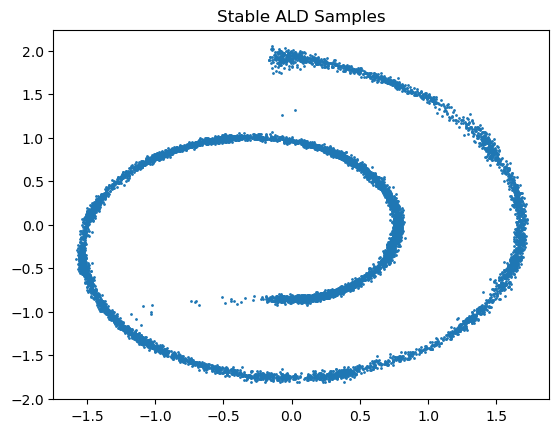

In [33]:
samples = x.detach().cpu().numpy()

plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.title("Stable ALD Samples")
plt.show()

Visually, the generated samples are more refined and closer to the original in this case, when compared to the single-noise level.
In this code, the sigma_max is chosen from the maximum pairwise distance between the original swiss roll points and the L and sigma_min from the recommendations made in the "imporved techniques" article

In [ ]:
bins = 100
H_real, xedges, yedges = np.histogram2d(
    X[:,0], X[:,1],
    bins=bins,
    density=True
)


H_generated, _, _ = np.histogram2d(
    samples[:,0],
    samples[:,1],
    bins=[xedges, yedges],
    density=True
)

difference = np.sum(np.abs(H_real - H_generated))
print(difference)


729.1527619515957


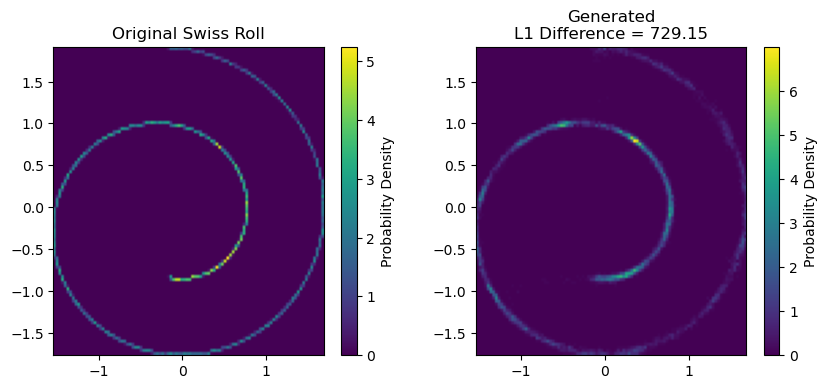

In [35]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1= ax[0].imshow(
    H_real.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[0].set_title("Original Swiss Roll")

im2=ax[1].imshow(
    H_generated.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[1].set_title(f"Generated\nL1 Difference = {difference:.2f}")

fig.colorbar(im1, ax=ax[0], label="Probability Density")
fig.colorbar(im2, ax=ax[1], label="Probability Density")
plt.show()

The L1 difference has reduced from 1214 to 729 when we switch from single to multi-noise levels and annealed Langevin sampling